## Imports and setup

In [1]:
import os
import json
import sys
from datetime import datetime
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader

import medmnist
from medmnist import INFO


# Resolve repo root:
# - If running inside notebooks/, go one level up
# - If already at repo root, keep it
try:
    NOTEBOOK_DIR = os.path.dirname(os.path.abspath(__file__))
except NameError:
    # In Jupyter, __file__ usually doesn't exist
    NOTEBOOK_DIR = os.getcwd()

# If this notebook lives in "notebooks/", repo root is its parent
if os.path.basename(NOTEBOOK_DIR) == "notebooks":
    REPO_ROOT = os.path.abspath(os.path.join(NOTEBOOK_DIR, ".."))
else:
    # Fall back to "one level up" behavior
    REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))

# Add repo root so `from src...` imports work
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

# Run-specific results directory
RESULTS_ROOT = os.path.join(REPO_ROOT, "results")
RUN_ID = datetime.now().strftime("%Y-%m-%d_%H.%M.%S")
RUN_DIR = os.path.join(RESULTS_ROOT, "runs", RUN_ID)
FIG_DIR = os.path.join(RUN_DIR, "figures")

os.makedirs(FIG_DIR, exist_ok=True)
print("Saving this run to:", RUN_DIR)

from src.model3d import Small3DCNN
from src.train_utils import TrainConfig, set_seed, train_one_epoch, evaluate, save_json, save_checkpoint

# ----------- Saving locations -----------

# Saving location for metrics 
metrics_path = os.path.join(RUN_DIR, "metrics.json")

# Saving location for plots 
train_loss_path = os.path.join(FIG_DIR, f"train_loss_{RUN_ID}.png")
confusion_matrix_path = os.path.join(FIG_DIR, f"confusion_matrix_{RUN_ID}.png")
table_path = os.path.join(FIG_DIR, f"results_table_{RUN_ID}.png")


Saving this run to: /Users/erem/Desktop/Desktop Folder/UBC/Fifth Year/Term 2/Cmpe 401/lung-nodule-3d/results/runs/2026-03-05_16.17.20


## Config and device

In [2]:
cfg = TrainConfig(
    epochs=10,
    lr=3e-4,
    weight_decay=1e-4,
    batch_size=128,

    # In macOS notebooks, multiprocessing can break with custom collate_fn
    # Keeping num_workers=0 avoids worker spawn/pickling issues
    num_workers=0,

    # Seed is set for more repeatable runs
    seed=42,

    # Default decision threshold for converting probability -> class label
    threshold=0.5
)

# Use GPU if available, otherwise CPU
device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

# Set random seeds across libraries to reduce run-to-run variation
set_seed(cfg.seed)

# Save plots and figures into this folder
os.makedirs("results/figures", exist_ok=True)

device: cpu


## Load NoduleMNIST3D

In [3]:
data_flag = "nodulemnist3d"
info = INFO[data_flag]

# Dataset class name is stored as a string in INFO; fetch the class object
DataClass = getattr(medmnist, info["python_class"])

print("Task:", info["task"])
print("Labels:", info["label"])
print("Channels:", info["n_channels"])

# Some MedMNIST versions omit n_classes; fallback to the number of labels
n_classes = info.get("n_classes", len(info["label"]))
print("Num classes:", n_classes)

Task: binary-class
Labels: {'0': 'benign', '1': 'malignant'}
Channels: 1
Num classes: 2


## Dataset Splitting

In [4]:
# MedMNIST downloads automatically to its cache location when download=True
train_ds = DataClass(split="train", download=True)
val_ds   = DataClass(split="val", download=True)
test_ds  = DataClass(split="test", download=True)

# Quick check - dataset sizes should match expected counts
print("sizes:", len(train_ds), len(val_ds), len(test_ds))

sizes: 1158 165 310


Important note: MedMNIST labels are typically shaped (N, 1). We’ll flatten later.

## DataLoader

In [5]:
# collate_fn controls how a list of dataset samples becomes a batch
def collate_fn(batch):
    xs, ys = zip(*batch)

    # Stack all volumes/labels into arrays, then convert to torch tensors
    x = torch.tensor(np.stack(xs)).float()
    y = torch.tensor(np.stack(ys)).long()

    # Some datasets may return (B, D, H, W); add channel dim if needed
    if x.ndim == 4:
        x = x.unsqueeze(1)

    return x, y

# pin_memory only helps when using CUDA; on CPU it can be left False
train_loader = DataLoader(
    train_ds,
    batch_size=cfg.batch_size,
    shuffle=True,
    num_workers=cfg.num_workers,
    pin_memory=False,
    collate_fn=collate_fn
)

val_loader = DataLoader(
    val_ds,
    batch_size=cfg.batch_size,
    shuffle=False,
    num_workers=cfg.num_workers,
    pin_memory=False,
    collate_fn=collate_fn
)

test_loader = DataLoader(
    test_ds,
    batch_size=cfg.batch_size,
    shuffle=False,
    num_workers=cfg.num_workers,
    pin_memory=False,
    collate_fn=collate_fn
)

## Data Visualization

x0 shape: (1, 28, 28, 28) y0: [0]


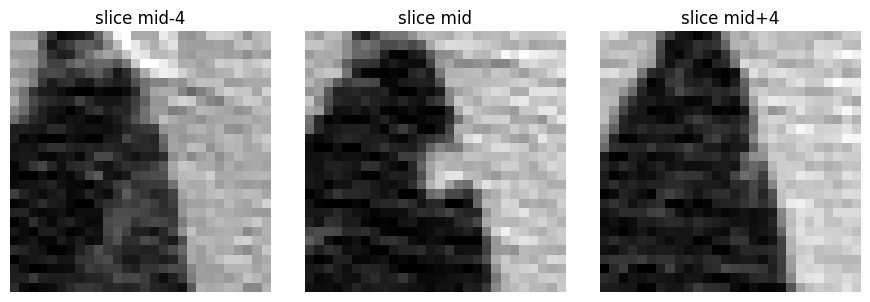

batch shapes: torch.Size([128, 1, 28, 28, 28]) torch.Size([128, 1])


In [6]:
# Inspect a single sample to confirm shapes and label format
x0, y0 = train_ds[0]
x0 = np.array(x0)
print("x0 shape:", x0.shape, "y0:", y0)

# For plotting, drop the channel dimension if present: (1, D, H, W) -> (D, H, W)
vol = x0[0] if x0.ndim == 4 else x0
mid = vol.shape[0] // 2

# Plot a few slices around the center depth
fig, axes = plt.subplots(1, 3, figsize=(9, 3))
axes[0].imshow(vol[mid-4], cmap="gray"); axes[0].set_title("slice mid-4"); axes[0].axis("off")
axes[1].imshow(vol[mid],   cmap="gray"); axes[1].set_title("slice mid");   axes[1].axis("off")
axes[2].imshow(vol[mid+4], cmap="gray"); axes[2].set_title("slice mid+4"); axes[2].axis("off")
plt.tight_layout()
plt.show()

# Confirm the DataLoader batch matches the 3D CNN expectation
xb, yb = next(iter(train_loader))
print("batch shapes:", xb.shape, yb.shape)

## Model, Loss, and Optimizer

In [7]:
# Model outputs a single logit for binary classification
model = Small3DCNN().to(device)

# BCEWithLogitsLoss expects raw logits
# Accounting for class imbalance to improve recall score
criterion = nn.BCEWithLogitsLoss()

# AdamW is a stable default for this small CNN baseline
optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)

print("num params:", sum(p.numel() for p in model.parameters()))

num params: 69953


## Training loop with metrics logging

In [8]:
# Store training loss and validation metrics per epoch
history = {"train_loss": [], "val": []}
best_score = -1.0
best_epoch = -1

for epoch in range(1, cfg.epochs + 1):
    # One full pass over the training set
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)

    # Evaluate on validation set at the current threshold
    val_metrics = evaluate(model, val_loader, device, threshold=cfg.threshold)

    history["train_loss"].append(train_loss)
    history["val"].append(val_metrics)

    print(
        f"epoch {epoch:02d} | loss {train_loss:.4f} | "
        f"val auroc {val_metrics['auroc']} | val f1 {val_metrics['f1']:.4f}"
    )

    # Saving location for results 
    best_ckpt_path = os.path.join(RUN_DIR, "best.pt")
    
    # Checkpoint selection: prefer AUROC when available; fallback to F1
    score = val_metrics["auroc"] if val_metrics["auroc"] is not None else val_metrics["f1"]
    if score > best_score:
        best_score = score
        best_epoch = epoch
        save_checkpoint(
            best_ckpt_path,
            model,
            optimizer,
            epoch,
            {"val_metrics": val_metrics, "config": cfg.__dict__}
        )

# Save training history and the best epoch so results are reproducible
save_json(metrics_path, {"history": history, "best_epoch": best_epoch})
print("best_epoch:", best_epoch, "best_score:", best_score)

epoch 01 | loss 0.7023 | val auroc 0.6451800232288037 | val f1 0.0000


epoch 02 | loss 0.6474 | val auroc 0.6612466124661247 | val f1 0.2909


epoch 03 | loss 0.5957 | val auroc 0.6838946960898181 | val f1 0.2642


epoch 04 | loss 0.5778 | val auroc 0.7415795586527295 | val f1 0.1333


epoch 05 | loss 0.5511 | val auroc 0.7164150212930701 | val f1 0.4211


epoch 06 | loss 0.5411 | val auroc 0.7510646535036779 | val f1 0.4561


epoch 07 | loss 0.5239 | val auroc 0.7866821525358111 | val f1 0.3200


epoch 08 | loss 0.5080 | val auroc 0.7775842044134726 | val f1 0.5747


epoch 09 | loss 0.4766 | val auroc 0.8012001548586914 | val f1 0.6364


epoch 10 | loss 0.4658 | val auroc 0.8062330623306233 | val f1 0.6111
best_epoch: 10 best_score: 0.8062330623306233


## Tuning Decision Threshold

In [9]:
# Collect logits and labels from a loader (used for threshold tuning)
@torch.no_grad()
def get_logits_and_labels(model, loader, device):
    model.eval()
    all_logits, all_y = [], []
    for x, y in loader:
        x = x.to(device)
        logits = model(x).cpu().numpy()
        all_logits.append(logits)

        # Labels arrive as shape (B, 1); flatten to (B,)
        all_y.append(y.numpy().reshape(-1))
    return np.concatenate(all_y).astype(int), np.concatenate(all_logits)

# Use validation set to choose a threshold (instead of guessing 0.5)
y_val, logits_val = get_logits_and_labels(model, val_loader, device)

from src.metrics import compute_binary_metrics

# Sweep thresholds and select the one that maximizes F1 on validation
thresholds = np.linspace(0.05, 0.95, 19)
rows = []
best = None

for t in thresholds:
    m = compute_binary_metrics(y_val, logits_val, threshold=float(t))
    row = (t, m["f1"], m["recall"], m["precision"], m["specificity"], m["accuracy"], m["auroc"])
    rows.append(row)
    
    # Track best threshold by F1 score
    if best is None or m["f1"] > best[1]:
        best = row

print("best by F1:", best)

best by F1: (np.float64(0.49999999999999994), 0.6111111111111112, 0.5238095238095238, 0.7333333333333333, 0.9349593495934959, 0.8303030303030303, 0.8062330623306233)


## Plot training curve

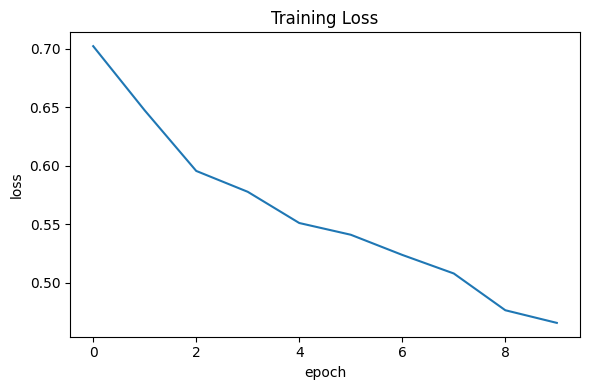

In [10]:
plt.figure(figsize=(6,4))
plt.plot(history["train_loss"])
plt.title("Training Loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.tight_layout()
plt.savefig(train_loss_path, dpi=200)
plt.show()

## Test evaluation 
### With default threshold and write into metrics.json

In [11]:
# Evaluate test set using the default threshold (0.5 unless changed)
test_metrics = evaluate(model, test_loader, device, threshold=cfg.threshold)
print(test_metrics)

# Store metrics in the same JSON file as training history
with open(metrics_path, "r") as f:
    m = json.load(f)
m["test_default_threshold"] = test_metrics
with open(metrics_path, "w") as f:
    json.dump(m, f, indent=2)

{'auroc': 0.8487677845528455, 'f1': 0.5641025641025641, 'accuracy': 0.8354838709677419, 'precision': 0.6226415094339622, 'recall': 0.515625, 'specificity': 0.9186991869918699, 'confusion_matrix': [[226, 20], [31, 33]]}


## Confusion matrix figure

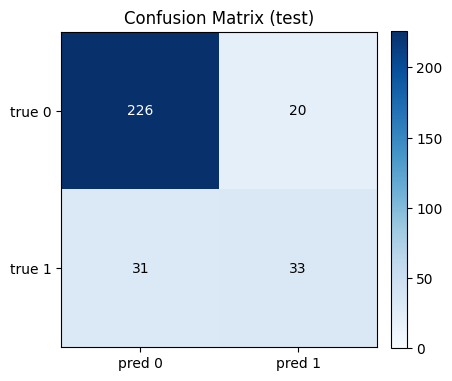

In [12]:
cm = np.array(test_metrics["confusion_matrix"])

plt.figure(figsize=(4.6, 4.2))
im = plt.imshow(cm, cmap="Blues", vmin=0, vmax=cm.max())
plt.colorbar(im, fraction=0.046, pad=0.04)

plt.title("Confusion Matrix (test)")
plt.xticks([0, 1], ["pred 0", "pred 1"])
plt.yticks([0, 1], ["true 0", "true 1"])

# text color that stays readable
thresh = cm.max() * 0.6
for i in range(2):
    for j in range(2):
        val = cm[i, j]
        txt_color = "white" if val > thresh else "black"
        plt.text(j, i, str(val), ha="center", va="center", color=txt_color)

plt.tight_layout()
plt.savefig(confusion_matrix_path, dpi=200)
plt.show()

## Threshold tuning on validation set

In [13]:
# Recompute best threshold in a structured dict format for saving
@torch.no_grad()
def get_logits_and_labels(model, loader, device):
    model.eval()  # eval mode for consistent inference (no dropout, BN uses running stats)

    all_logits, all_y = [], []
    for x, y in loader:
        x = x.to(device)                     # move batch to CPU/GPU
        logits = model(x).cpu().numpy()       # forward pass -> raw logits (B,)
        all_logits.append(logits)

        all_y.append(y.numpy().reshape(-1))   # labels often come as (B,1); flatten to (B,)

    # combine batches into full arrays for the whole split
    return np.concatenate(all_y).astype(int), np.concatenate(all_logits)

# get validation labels + logits once, then sweep thresholds cheaply
y_val, logits_val = get_logits_and_labels(model, val_loader, device)

# try a range of thresholds; pick the one that maximizes F1 on validation
thresholds = np.linspace(0.05, 0.95, 19)
rows = []
best = None

for t in thresholds:
    met = compute_binary_metrics(y_val, logits_val, threshold=float(t))  # metrics at this threshold
    row = {
        "threshold": float(t),
        "f1": met["f1"],
        "recall": met["recall"],
        "precision": met["precision"],
        "specificity": met["specificity"],
        "accuracy": met["accuracy"],
        "auroc": met["auroc"],
    }
    rows.append(row)

    if best is None or row["f1"] > best["f1"]:
        best = row

print("best threshold by F1:", best)


best threshold by F1: {'threshold': 0.49999999999999994, 'f1': 0.6111111111111112, 'recall': 0.5238095238095238, 'precision': 0.7333333333333333, 'specificity': 0.9349593495934959, 'accuracy': 0.8303030303030303, 'auroc': 0.8062330623306233}


## Test evaluation with tuned threshold

In [14]:
# evaluate test set once using the chosen threshold
best_threshold = best["threshold"]
test_metrics_tuned = evaluate(model, test_loader, device, threshold=best_threshold)
print("threshold:", best_threshold)
print(test_metrics_tuned)

# write tuned-threshold results into the metrics.json file
with open(metrics_path, "r") as f:
    m = json.load(f)
m["best_threshold_val_f1"] = best
m["test_tuned_threshold"] = test_metrics_tuned
with open(metrics_path, "w") as f:
    json.dump(m, f, indent=2)

threshold: 0.49999999999999994
{'auroc': 0.8487677845528455, 'f1': 0.5641025641025641, 'accuracy': 0.8354838709677419, 'precision': 0.6226415094339622, 'recall': 0.515625, 'specificity': 0.9186991869918699, 'confusion_matrix': [[226, 20], [31, 33]]}


## Logistic regression baseline 
### With flattened voxels

In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

def flatten_dataset(ds):
    X, y = [], []
    for i in range(len(ds)):
        x_i, y_i = ds[i]
        x_i = np.array(x_i).astype(np.float32)  # expected (1, 28, 28, 28)
        X.append(x_i.reshape(-1))               # flatten -> (28*28*28,)

        y.append(int(np.array(y_i).reshape(-1)[0]))  # label stored as (1,); convert to int

    return np.stack(X), np.array(y)

# build feature matrices for each split
X_train, y_train = flatten_dataset(train_ds)
X_val_lr, y_val_lr = flatten_dataset(val_ds)
X_test, y_test = flatten_dataset(test_ds)

# standardize features + train class-weighted logistic regression
clf = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=2000, class_weight="balanced")
)
clf.fit(X_train, y_train)

# decision_function gives raw scores (logit-like) suitable for AUROC + thresholding
logits_test_lr = clf.decision_function(X_test)
lr_metrics = compute_binary_metrics(y_test, logits_test_lr, threshold=0.5)
print(lr_metrics)

# save baseline results into metrics.json
with open(metrics_path, "r") as f:
    m = json.load(f)
m["logreg_baseline_test"] = lr_metrics
with open(metrics_path, "w") as f:
    json.dump(m, f, indent=2)

{'auroc': 0.8226626016260161, 'f1': 0.5538461538461539, 'accuracy': 0.8129032258064516, 'precision': 0.5454545454545454, 'recall': 0.5625, 'specificity': 0.8780487804878049, 'confusion_matrix': [[216, 30], [28, 36]]}


## Results summary table

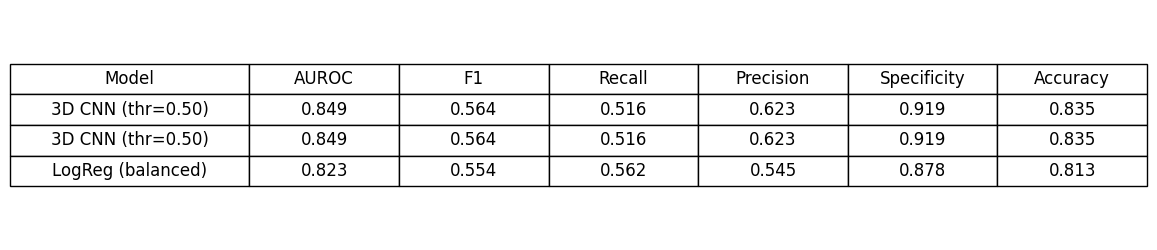

In [18]:
fig, ax = plt.subplots(figsize=(12, 2.6))  # wider + a bit taller
ax.axis("off")

table = ax.table(
    cellText=cell_text,
    colLabels=col_labels,
    loc="center",
    cellLoc="center",
)

# Bigger text + bigger cells
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.25, 1.6)   # (x scale, y scale)

# Make the first column wider (model names)
# This is a simple manual tweak that usually looks better.
for (r, c), cell in table.get_celld().items():
    if c == 0:
        cell.set_width(cell.get_width() * 1.6)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, f"results_table_{RUN_ID}.png"), dpi=300)
plt.show()